# Credit Card Fraud Detection - Exploratory Data Analysis

## Overview
This notebook performs comprehensive exploratory data analysis on the credit card fraud detection dataset to understand:
- Dataset structure and characteristics
- Class distribution (fraud vs non-fraud)
- Transaction patterns and amounts
- Temporal patterns
- Geographic patterns
- Correlation between features
- Key insights for model building

In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inline
%matplotlib inline


## 1. Load and Initial Data Inspection

In [2]:
# Load dataset
df = pd.read_csv('../data/raw/fraudTest.csv')

print(f"\nDataset Shape: {df.shape}")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")


Dataset Shape: (555719, 23)
Number of rows: 555,719
Number of columns: 23


In [3]:
# Display first few rows
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


## 2. Dataset Information and Structure

In [4]:
# Basic info about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [5]:
# Summary statistics for numerical columns
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,277859.000000,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,555718.000000,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


In [6]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Count': missing_values.values,
    'Missing Percentage': missing_percent.values
})

missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
else:
    print("\nNo missing values found")

print(f"\nTotal columns: {len(df.columns)}")
print(f"Columns with missing values: {len(missing_df)}")


No missing values found

Total columns: 23
Columns with missing values: 0


## 3. Target Variable Analysis (is_fraud)

In [7]:
# Target variable distribution
fraud_counts = df['is_fraud'].value_counts()
fraud_percentages = df['is_fraud'].value_counts(normalize=True) * 100

print("\nFraud Class Counts:")
print(fraud_counts)
print("\nFraud Class Percentages:")
print(fraud_percentages)

print("\n" + "-"*60)
print(f"Total transactions: {len(df):,}")
print(f"Fraudulent transactions: {fraud_counts[1]:,} ({fraud_percentages[1]:.2f}%)")
print(f"Legitimate transactions: {fraud_counts[0]:,} ({fraud_percentages[0]:.2f}%)")
print(f"Imbalance ratio: {fraud_counts[0]/fraud_counts[1]:.2f}:1")


Fraud Class Counts:
is_fraud
0    553574
1      2145
Name: count, dtype: int64

Fraud Class Percentages:
is_fraud
0    99.614014
1     0.385986
Name: proportion, dtype: float64

------------------------------------------------------------
Total transactions: 555,719
Fraudulent transactions: 2,145 (0.39%)
Legitimate transactions: 553,574 (99.61%)
Imbalance ratio: 258.08:1


C:\Users\N I T R O\AppData\Local\Temp\ipykernel_56436\1889808734.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_fraud', data=df, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
C:\Users\N I T R O\AppData\Local\Temp\ipykernel_56436\1889808734.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Legitimate', 'Fraud'])


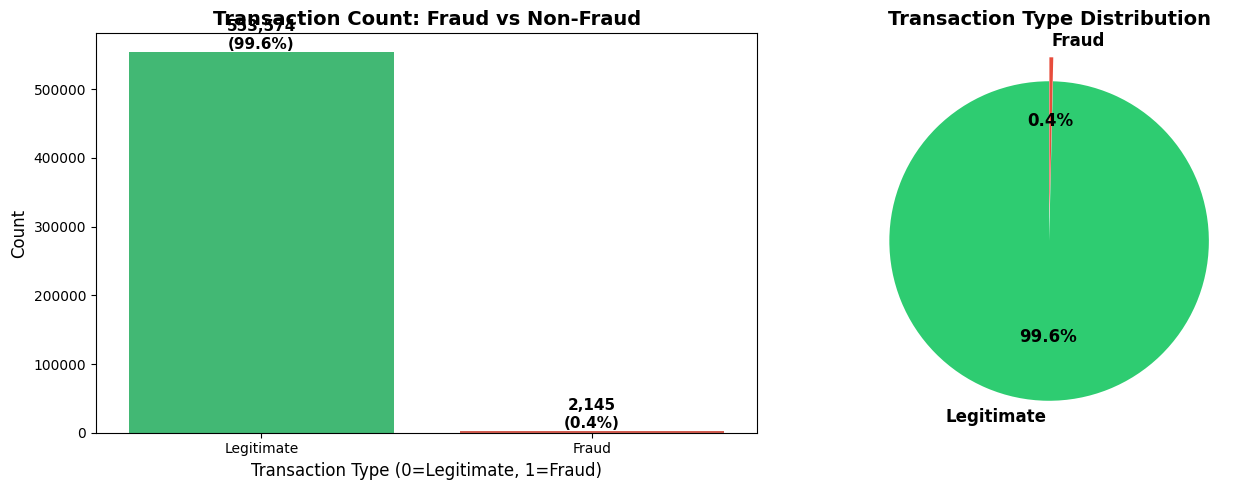


💡 INSIGHT: The dataset is highly imbalanced with only 0.5% fraudulent transactions.
   This is typical for fraud detection and will require special handling during modeling.


In [8]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(x='is_fraud', data=df, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Transaction Count: Fraud vs Non-Fraud', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Transaction Type (0=Legitimate, 1=Fraud)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(['Legitimate', 'Fraud'])

# Add count labels on bars
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({fraud_percentages[i]:.1f}%)', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
colors = ['#2ecc71', '#e74c3c']
explode = (0.05, 0.1)
axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraud'], 
            autopct='%1.1f%%', startangle=90, colors=colors, explode=explode,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Transaction Type Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT: The dataset is highly imbalanced with only 0.5% fraudulent transactions.")
print("   This is typical for fraud detection and will require special handling during modeling.")

## 4. Transaction Amount Analysis

In [9]:
# Transaction amount analysis by fraud status
print("="*60)
print("TRANSACTION AMOUNT ANALYSIS BY FRAUD STATUS")
print("="*60)

amount_stats = df.groupby('is_fraud')['amt'].describe()
print(amount_stats)

TRANSACTION AMOUNT ANALYSIS BY FRAUD STATUS
             count        mean         std   min     25%     50%     75%  \
is_fraud                                                                   
0         553574.0   67.614408  152.471931  1.00    9.60   47.15   82.62   
1           2145.0  528.356494  392.747594  1.78  214.51  371.94  907.77   

               max  
is_fraud            
0         22768.11  
1          1320.92  


C:\Users\N I T R O\AppData\Local\Temp\ipykernel_56436\1531223543.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_fraud', y='amt', data=df[df['amt'] <= 500], ax=axes[1, 1], palette=['#2ecc71', '#e74c3c'])
C:\Users\N I T R O\AppData\Local\Temp\ipykernel_56436\1531223543.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['Legitimate', 'Fraud'])


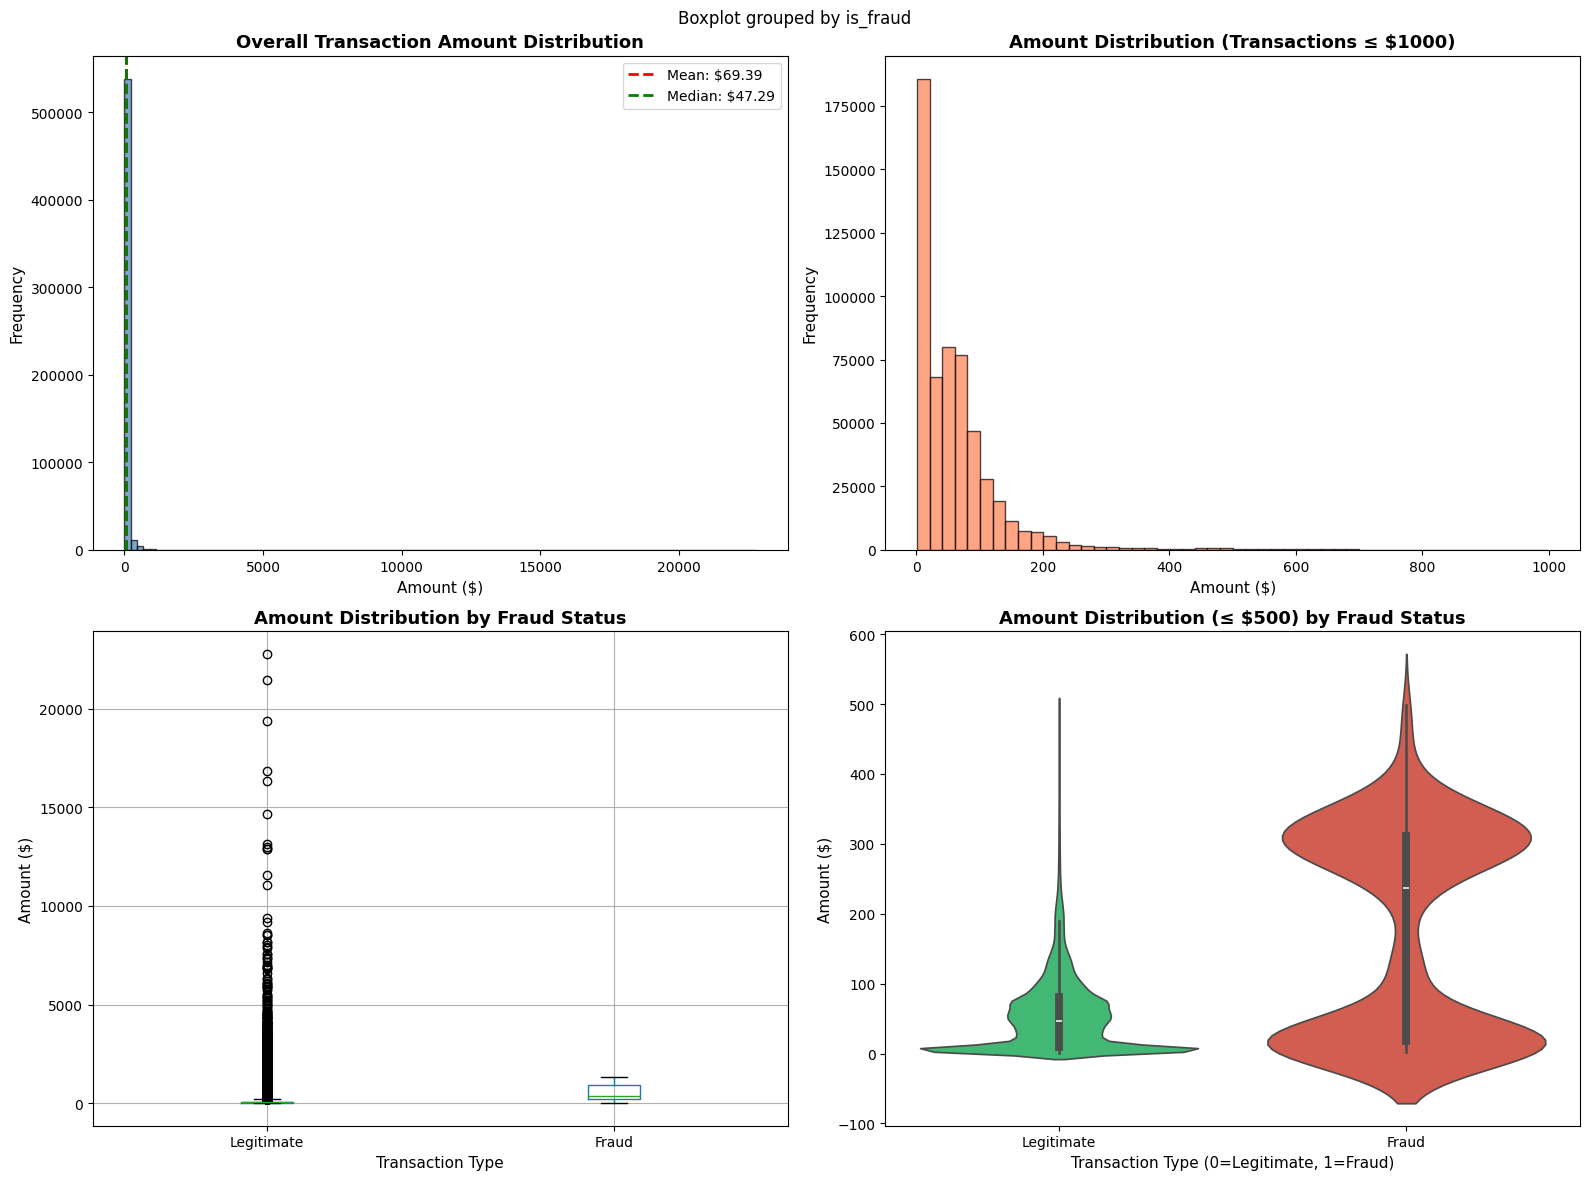


💡 INSIGHT: Fraudulent transactions tend to have higher average amounts than legitimate ones.
   The median amount for fraud is significantly higher, suggesting fraudsters target larger transactions.


In [10]:
# Visualize amount distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Overall amount distribution
axes[0, 0].hist(df['amt'], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Overall Transaction Amount Distribution', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Amount ($)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].axvline(df['amt'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${df["amt"].mean():.2f}')
axes[0, 0].axvline(df['amt'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: ${df["amt"].median():.2f}')
axes[0, 0].legend()

# Amount distribution (0-1000) - focus on most transactions
axes[0, 1].hist(df[df['amt'] <= 1000]['amt'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Amount Distribution (Transactions ≤ $1000)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Amount ($)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)

# Box plot by fraud status
df.boxplot(column='amt', by='is_fraud', ax=axes[1, 0])

axes[1, 0].set_title('Amount Distribution by Fraud Status', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Transaction Type', fontsize=11)
axes[1, 0].set_ylabel('Amount ($)', fontsize=11)

axes[1, 0].set_xticks([1, 2])
axes[1, 0].set_xticklabels(['Legitimate', 'Fraud'])

# Violin plot
sns.violinplot(x='is_fraud', y='amt', data=df[df['amt'] <= 500], ax=axes[1, 1], palette=['#2ecc71', '#e74c3c'])
axes[1, 1].set_title('Amount Distribution (≤ $500) by Fraud Status', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Transaction Type (0=Legitimate, 1=Fraud)', fontsize=11)
axes[1, 1].set_ylabel('Amount ($)', fontsize=11)
axes[1, 1].set_xticklabels(['Legitimate', 'Fraud'])

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT: Fraudulent transactions tend to have higher average amounts than legitimate ones.")
print("   The median amount for fraud is significantly higher, suggesting fraudsters target larger transactions.")

## 5. Temporal Analysis

In [11]:
# Convert datetime columns
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

# Extract temporal features
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['month'] = df['trans_date_trans_time'].dt.month
df['year'] = df['trans_date_trans_time'].dt.year

print("✓ Datetime features extracted successfully!")
print(f"\nDate range: {df['trans_date_trans_time'].min()} to {df['trans_date_trans_time'].max()}")

✓ Datetime features extracted successfully!

Date range: 2020-06-21 12:14:25 to 2020-12-31 23:59:34


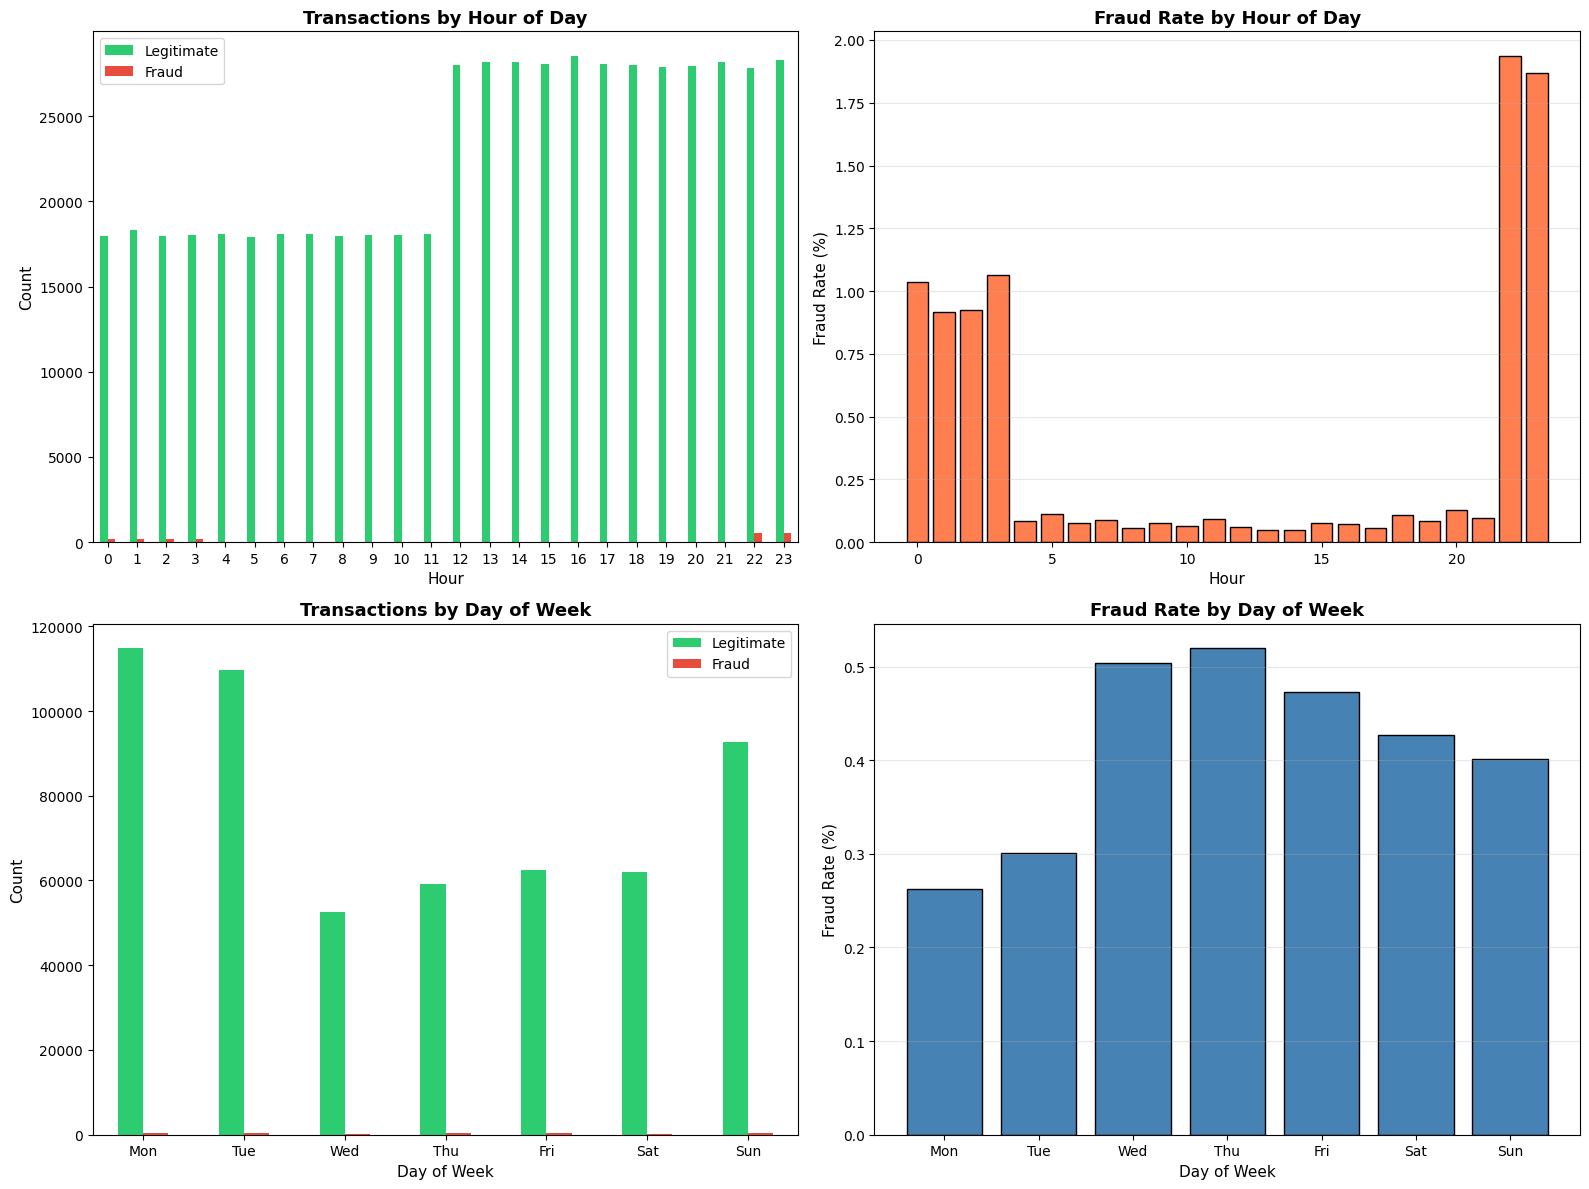


💡 INSIGHT: Fraud patterns vary by time, with certain hours showing higher fraud rates.
   Late night and early morning hours may have elevated fraud risk.


In [12]:
# Hourly fraud analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Transactions by hour
hourly_counts = df.groupby(['hour', 'is_fraud']).size().unstack(fill_value=0)
hourly_counts.plot(kind='bar', ax=axes[0, 0], color=['#2ecc71', '#e74c3c'])
axes[0, 0].set_title('Transactions by Hour of Day', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Hour', fontsize=11)
axes[0, 0].set_ylabel('Count', fontsize=11)
axes[0, 0].legend(['Legitimate', 'Fraud'])
axes[0, 0].tick_params(axis='x', rotation=0)

# Fraud rate by hour
hourly_fraud_rate = df.groupby('hour')['is_fraud'].mean() * 100
axes[0, 1].bar(hourly_fraud_rate.index, hourly_fraud_rate.values, color='coral', edgecolor='black')
axes[0, 1].set_title('Fraud Rate by Hour of Day', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Hour', fontsize=11)
axes[0, 1].set_ylabel('Fraud Rate (%)', fontsize=11)
axes[0, 1].grid(axis='y', alpha=0.3)

# Transactions by day of week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_counts = df.groupby(['day_of_week', 'is_fraud']).size().unstack(fill_value=0)
daily_counts.plot(kind='bar', ax=axes[1, 0], color=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Transactions by Day of Week', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Day of Week', fontsize=11)
axes[1, 0].set_ylabel('Count', fontsize=11)
axes[1, 0].legend(['Legitimate', 'Fraud'])
axes[1, 0].set_xticklabels(day_names, rotation=0)

# Fraud rate by day of week
daily_fraud_rate = df.groupby('day_of_week')['is_fraud'].mean() * 100
axes[1, 1].bar(range(len(day_names)), daily_fraud_rate.values, color='steelblue', edgecolor='black')
axes[1, 1].set_title('Fraud Rate by Day of Week', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Day of Week', fontsize=11)
axes[1, 1].set_ylabel('Fraud Rate (%)', fontsize=11)
axes[1, 1].set_xticks(range(len(day_names)))
axes[1, 1].set_xticklabels(day_names)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 INSIGHT: Fraud patterns vary by time, with certain hours showing higher fraud rates.")
print("   Late night and early morning hours may have elevated fraud risk.")

## 6. Geographic Analysis

In [13]:
# State-level fraud analysis
print("="*60)
print("STATE-LEVEL FRAUD ANALYSIS")
print("="*60)

state_fraud = df.groupby('state').agg({
    'is_fraud': ['count', 'sum', 'mean']
}).round(4)
state_fraud.columns = ['Total_Transactions', 'Fraud_Count', 'Fraud_Rate']
state_fraud = state_fraud.sort_values('Fraud_Rate', ascending=False)

print("\nTop 10 States by Fraud Rate:")
print(state_fraud.head(10))

STATE-LEVEL FRAUD ANALYSIS

Top 10 States by Fraud Rate:
       Total_Transactions  Fraud_Count  Fraud_Rate
state                                             
AK                    843           14      0.0166
CT                   3277           40      0.0122
ID                   2490           22      0.0088
HI                   1090            9      0.0083
MT                   5052           37      0.0073
DC                   1517           10      0.0066
IN                  11959           75      0.0063
MS                   8833           54      0.0061
OR                   7811           48      0.0061
VA                  12506           75      0.0060


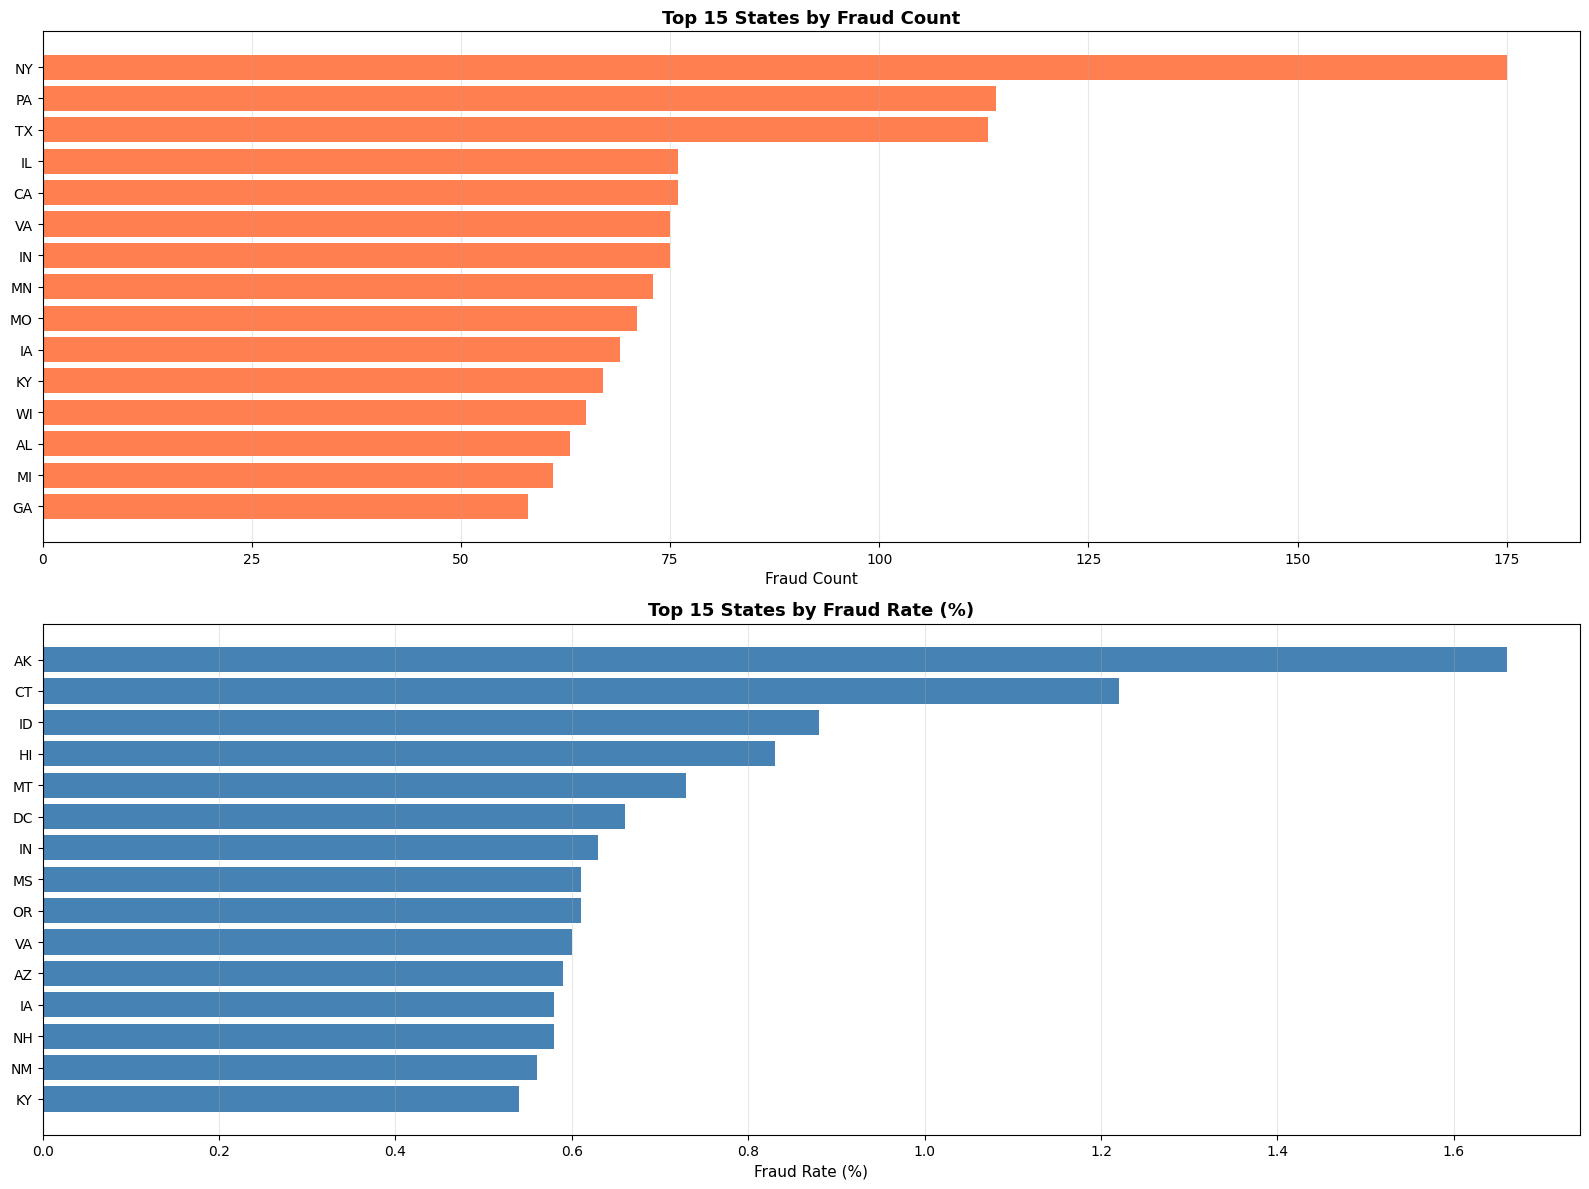

In [14]:
# Visualize state-level fraud
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Top 15 states by fraud count
top_states_count = state_fraud.sort_values('Fraud_Count', ascending=False).head(15)
axes[0].barh(range(len(top_states_count)), top_states_count['Fraud_Count'], color='coral')
axes[0].set_yticks(range(len(top_states_count)))
axes[0].set_yticklabels(top_states_count.index)
axes[0].set_title('Top 15 States by Fraud Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Fraud Count', fontsize=11)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Top 15 states by fraud rate
top_states_rate = state_fraud.sort_values('Fraud_Rate', ascending=False).head(15)
axes[1].barh(range(len(top_states_rate)), top_states_rate['Fraud_Rate'] * 100, color='steelblue')
axes[1].set_yticks(range(len(top_states_rate)))
axes[1].set_yticklabels(top_states_rate.index)
axes[1].set_title('Top 15 States by Fraud Rate (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Fraud Rate (%)', fontsize=11)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Categorical Features Analysis

In [15]:
# Category analysis
print("="*60)
print("MERCHANT CATEGORY ANALYSIS")
print("="*60)

category_fraud = df.groupby('category').agg({
    'is_fraud': ['count', 'sum', 'mean']
}).round(4)
category_fraud.columns = ['Total_Count', 'Fraud_Count', 'Fraud_Rate']
category_fraud = category_fraud.sort_values('Fraud_Rate', ascending=False)

print(category_fraud)

MERCHANT CATEGORY ANALYSIS
                Total_Count  Fraud_Count  Fraud_Rate
category                                            
shopping_net          41779          506      0.0121
misc_net              27367          267      0.0098
grocery_pos           52553          485      0.0092
shopping_pos          49791          213      0.0043
gas_transport         56370          154      0.0027
travel                17449           40      0.0023
grocery_net           19426           41      0.0021
misc_pos              34574           72      0.0021
personal_care         39327           70      0.0018
entertainment         40104           59      0.0015
food_dining           39268           54      0.0014
health_fitness        36674           52      0.0014
home                  52345           67      0.0013
kids_pets             48692           65      0.0013


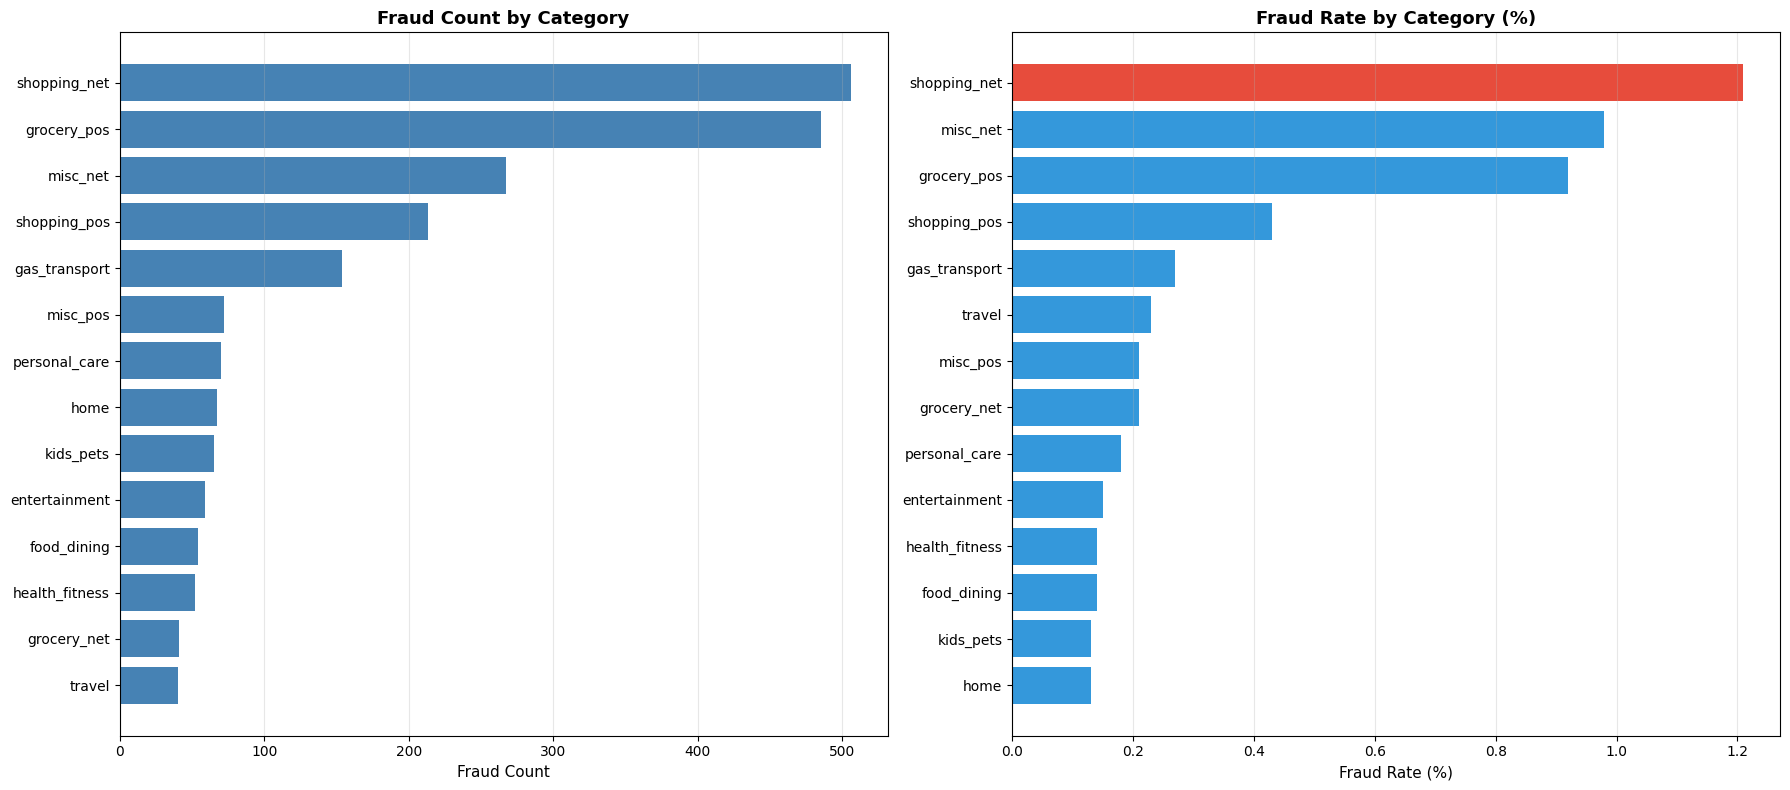

In [16]:
# Visualize category fraud rates
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Fraud count by category
category_fraud_sorted = category_fraud.sort_values('Fraud_Count', ascending=True)
axes[0].barh(range(len(category_fraud_sorted)), category_fraud_sorted['Fraud_Count'], color='steelblue')
axes[0].set_yticks(range(len(category_fraud_sorted)))
axes[0].set_yticklabels(category_fraud_sorted.index, fontsize=10)
axes[0].set_title('Fraud Count by Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Fraud Count', fontsize=11)
axes[0].grid(axis='x', alpha=0.3)

# Fraud rate by category
category_fraud_sorted_rate = category_fraud.sort_values('Fraud_Rate', ascending=True)
axes[1].barh(range(len(category_fraud_sorted_rate)), category_fraud_sorted_rate['Fraud_Rate'] * 100, 
            color=['#e74c3c' if x > 0.01 else '#3498db' for x in category_fraud_sorted_rate['Fraud_Rate']])
axes[1].set_yticks(range(len(category_fraud_sorted_rate)))
axes[1].set_yticklabels(category_fraud_sorted_rate.index, fontsize=10)
axes[1].set_title('Fraud Rate by Category (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Fraud Rate (%)', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

GENDER ANALYSIS
        Total_Count  Fraud_Count  Fraud_Rate
gender                                      
F            304886         1164      0.0038
M            250833          981      0.0039


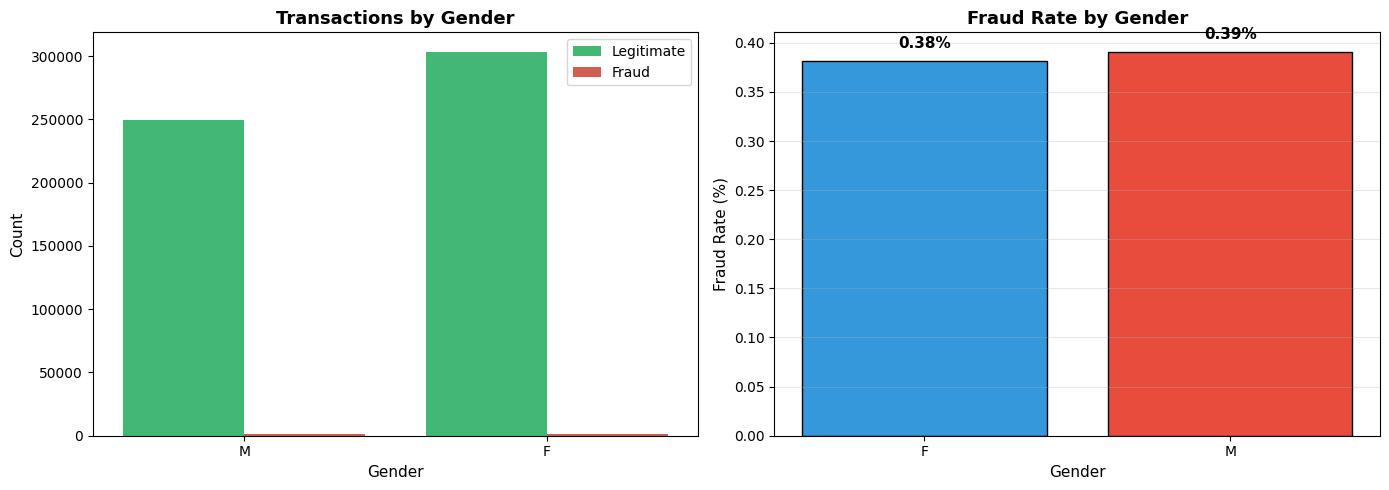

In [17]:
# Gender analysis
print("="*60)
print("GENDER ANALYSIS")
print("="*60)

gender_fraud = df.groupby('gender').agg({
    'is_fraud': ['count', 'sum', 'mean']
}).round(4)
gender_fraud.columns = ['Total_Count', 'Fraud_Count', 'Fraud_Rate']
print(gender_fraud)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(x='gender', hue='is_fraud', data=df, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Transactions by Gender', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(['Legitimate', 'Fraud'])

# Fraud rate
gender_fraud_rate = df.groupby('gender')['is_fraud'].mean() * 100
axes[1].bar(gender_fraud_rate.index, gender_fraud_rate.values, color=['#3498db', '#e74c3c'], edgecolor='black')
axes[1].set_title('Fraud Rate by Gender', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=11)
axes[1].set_ylabel('Fraud Rate (%)', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(gender_fraud_rate.values):
    axes[1].text(i, v + 0.01, f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Correlation Analysis

In [18]:
# Correlation analysis
print("="*60)
print("CORRELATION ANALYSIS")
print("="*60)

# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns: {len(numeric_cols)}")

# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr()

# Display correlations with target
print("\nCorrelations with 'is_fraud' (sorted by absolute value):")
target_corr = corr_matrix['is_fraud'].abs().sort_values(ascending=False)
print(target_corr)

CORRELATION ANALYSIS

Numeric columns: 15

Correlations with 'is_fraud' (sorted by absolute value):
is_fraud       1.000000
amt            0.182267
Unnamed: 0     0.013892
unix_time      0.013066
month          0.011748
hour           0.011686
day_of_week    0.009365
lat            0.005863
merch_lat      0.005812
city_pop       0.004910
zip            0.002271
cc_num         0.001540
merch_long     0.001060
long           0.000972
year                NaN
Name: is_fraud, dtype: float64


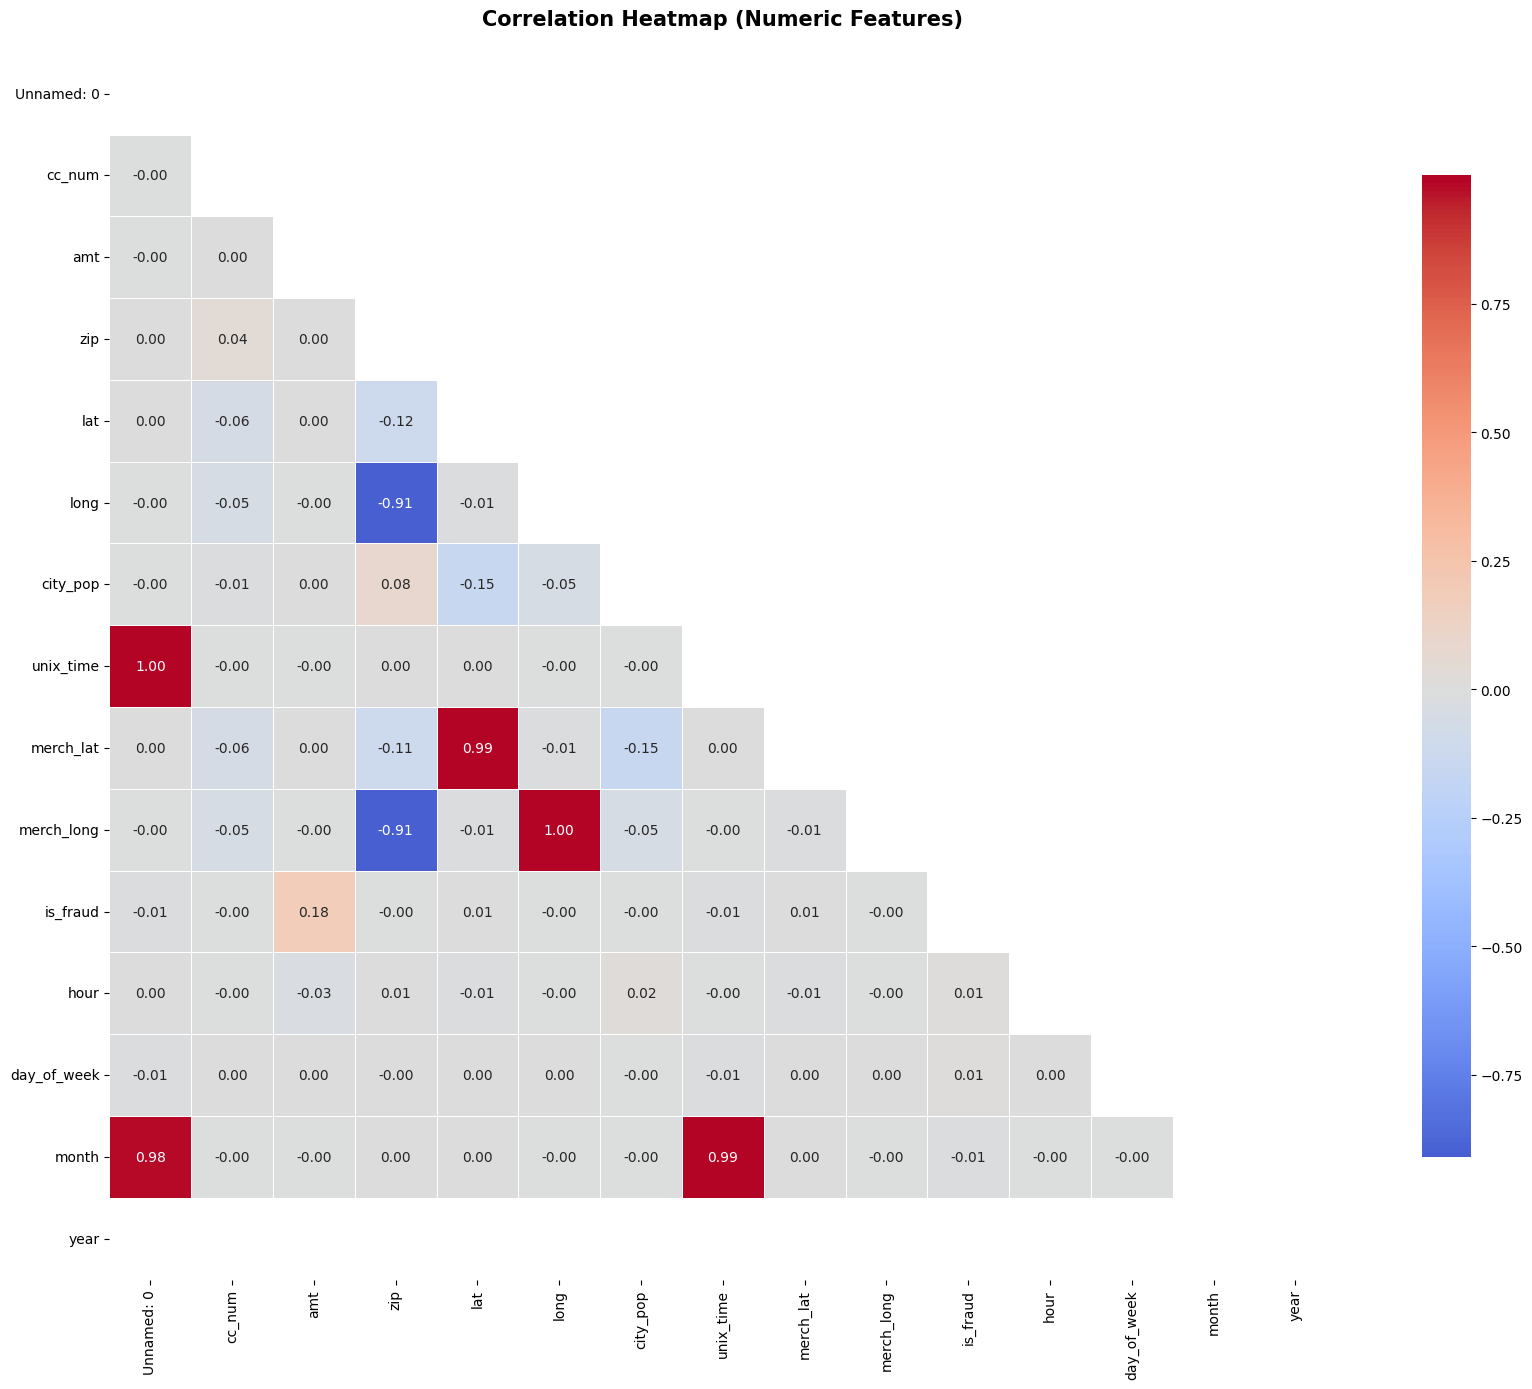


💡 INSIGHT: Look for strong correlations (both positive and negative) with 'is_fraud'.
   Also check for multicollinearity between independent features.


In [19]:
# Correlation heatmap
plt.figure(figsize=(18, 14))

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Generate heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap (Numeric Features)', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n💡 INSIGHT: Look for strong correlations (both positive and negative) with 'is_fraud'.")
print("   Also check for multicollinearity between independent features.")

## 9. Age Analysis

In [20]:
# Calculate age from date of birth
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days / 365.25
df['age'] = df['age'].astype(int)

print("="*60)
print("AGE ANALYSIS")
print("="*60)
print(df.groupby('is_fraud')['age'].describe())

AGE ANALYSIS
             count       mean        std   min   25%   50%   75%   max
is_fraud                                                              
0         553574.0  46.382538  17.431056  15.0  33.0  44.0  58.0  96.0
1           2145.0  48.444289  17.611923  18.0  34.0  47.0  61.0  95.0


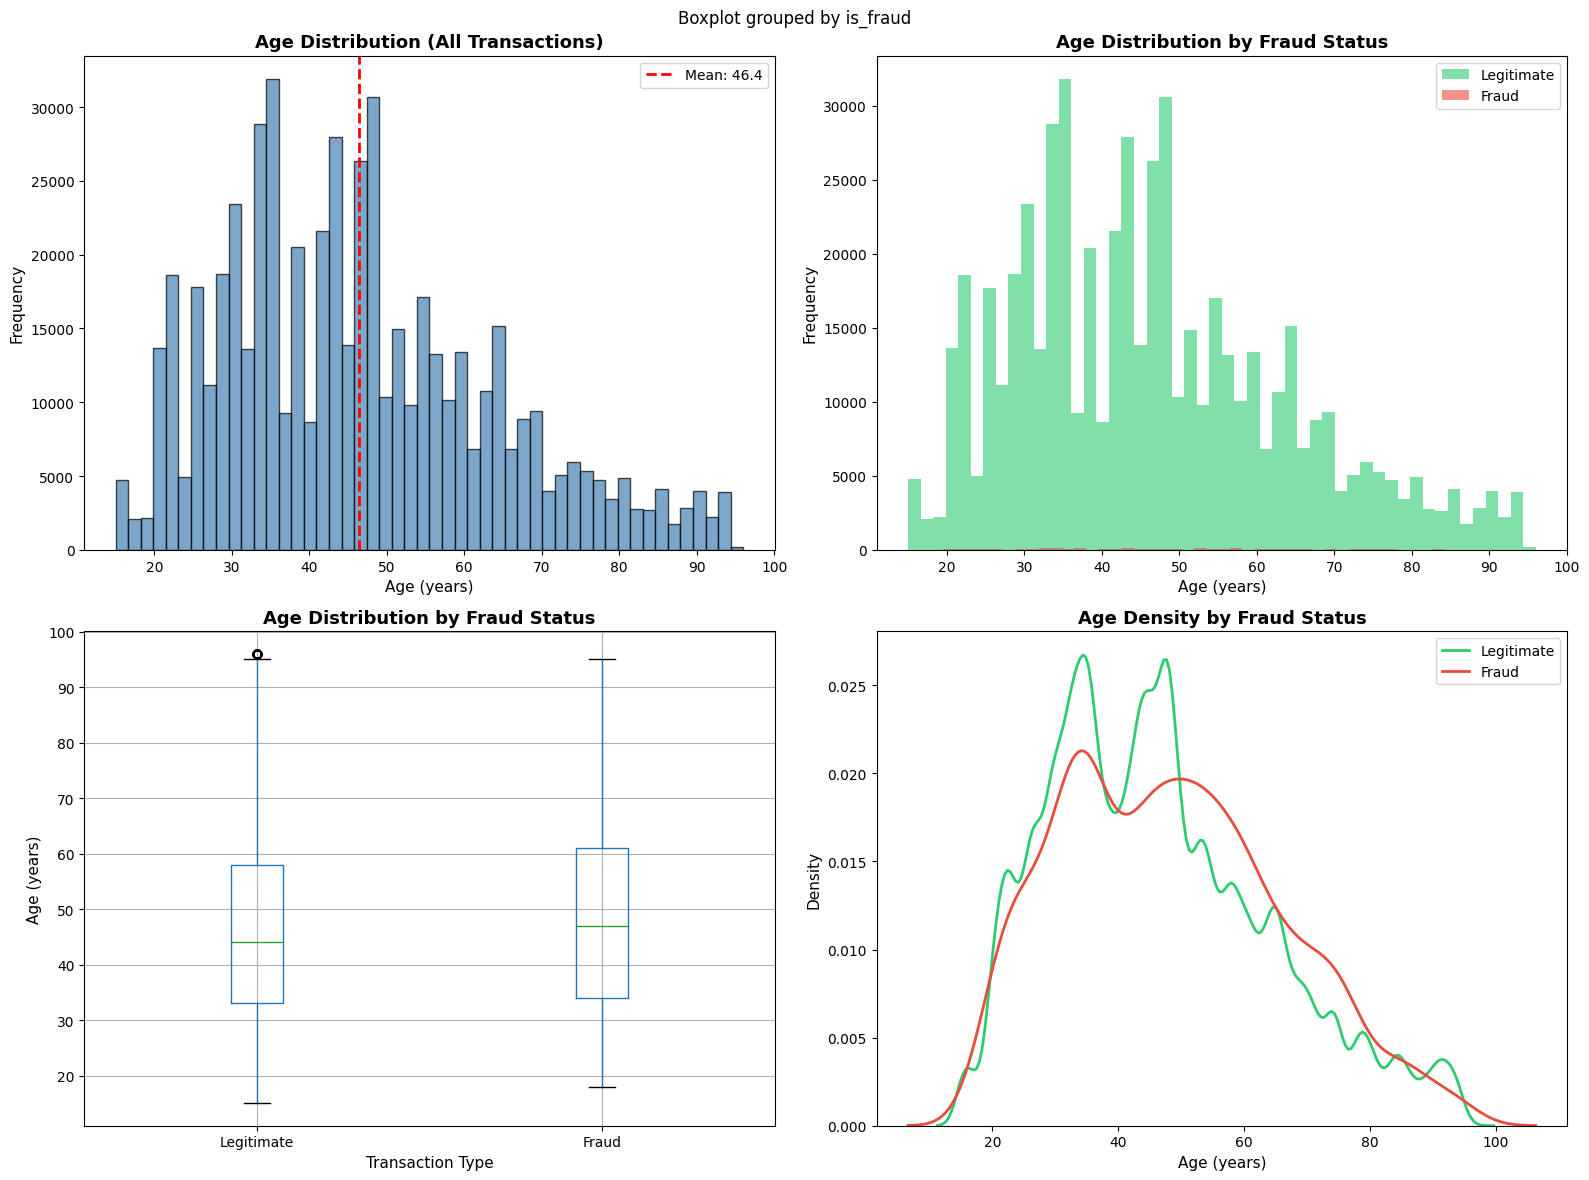

In [21]:
# Visualize age distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Age distribution overall
axes[0, 0].hist(df['age'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Age Distribution (All Transactions)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Age (years)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["age"].mean():.1f}')
axes[0, 0].legend()

# Age distribution by fraud
axes[0, 1].hist(df[df['is_fraud'] == 0]['age'], bins=50, alpha=0.6, label='Legitimate', color='#2ecc71')
axes[0, 1].hist(df[df['is_fraud'] == 1]['age'], bins=50, alpha=0.6, label='Fraud', color='#e74c3c')
axes[0, 1].set_title('Age Distribution by Fraud Status', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Age (years)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].legend()

# Box plot
df.boxplot(column='age', by='is_fraud', ax=axes[1, 0])

axes[1, 0].set_title('Age Distribution by Fraud Status', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Transaction Type', fontsize=11)
axes[1, 0].set_ylabel('Age (years)', fontsize=11)

# Correct x-axis labels
axes[1, 0].set_xticks([1, 2])
axes[1, 0].set_xticklabels(['Legitimate', 'Fraud'])

# KDE plot
sns.kdeplot(data=df[df['is_fraud'] == 0], x='age', ax=axes[1, 1], label='Legitimate', color='#2ecc71', linewidth=2)
sns.kdeplot(data=df[df['is_fraud'] == 1], x='age', ax=axes[1, 1], label='Fraud', color='#e74c3c', linewidth=2)
axes[1, 1].set_title('Age Density by Fraud Status', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Age (years)', fontsize=11)
axes[1, 1].set_ylabel('Density', fontsize=11)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 10. City Population Analysis

In [22]:
# City population analysis
print("="*60)
print("CITY POPULATION ANALYSIS")
print("="*60)

print(df.groupby('is_fraud')['city_pop'].describe())

CITY POPULATION ANALYSIS
             count          mean            std   min     25%     50%  \
is_fraud                                                                
0         553574.0  88313.692365  300659.345969  23.0   741.0  2408.0   
1           2145.0  64529.321678  219207.458844  23.0  1131.0  2870.0   

              75%        max  
is_fraud                      
0         19685.0  2906700.0  
1         12335.0  1577385.0  


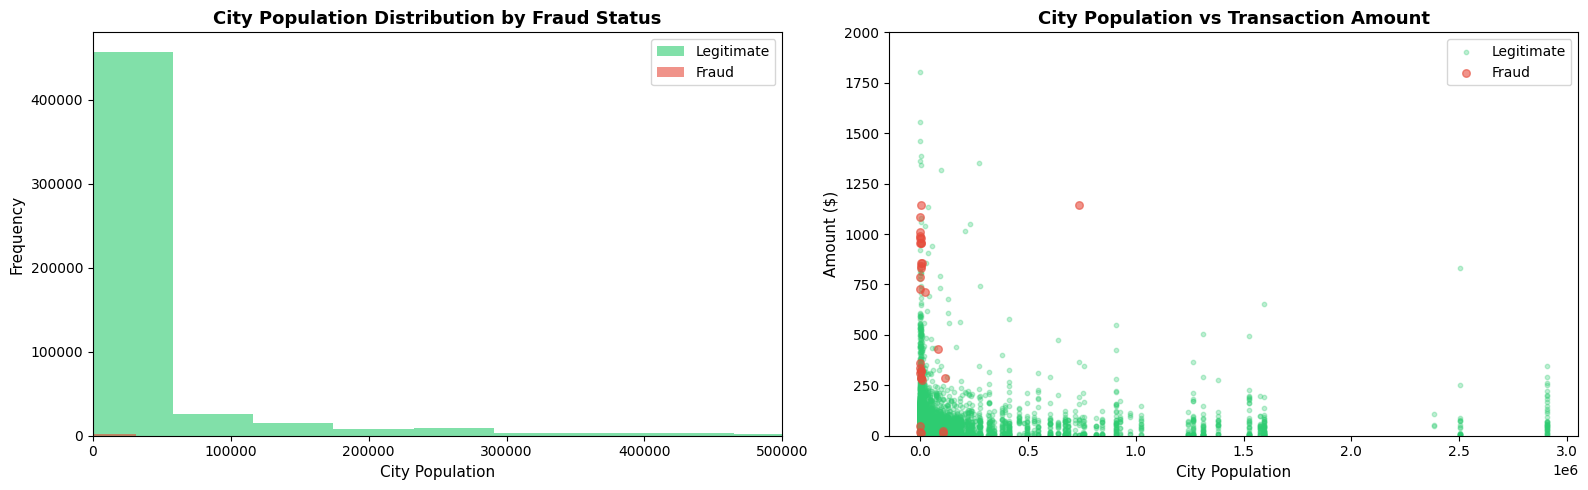

In [23]:
# Visualize city population
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
axes[0].hist(df[df['is_fraud'] == 0]['city_pop'], bins=50, alpha=0.6, label='Legitimate', color='#2ecc71')
axes[0].hist(df[df['is_fraud'] == 1]['city_pop'], bins=50, alpha=0.6, label='Fraud', color='#e74c3c')
axes[0].set_title('City Population Distribution by Fraud Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('City Population', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].legend()
axes[0].set_xlim(0, 500000)

# Scatter plot: city_pop vs amount
sample_df = df.sample(10000, random_state=42)  # Sample for visualization
axes[1].scatter(sample_df[sample_df['is_fraud'] == 0]['city_pop'], 
               sample_df[sample_df['is_fraud'] == 0]['amt'], 
               alpha=0.3, label='Legitimate', color='#2ecc71', s=10)
axes[1].scatter(sample_df[sample_df['is_fraud'] == 1]['city_pop'], 
               sample_df[sample_df['is_fraud'] == 1]['amt'], 
               alpha=0.6, label='Fraud', color='#e74c3c', s=30)
axes[1].set_title('City Population vs Transaction Amount', fontsize=13, fontweight='bold')
axes[1].set_xlabel('City Population', fontsize=11)
axes[1].set_ylabel('Amount ($)', fontsize=11)
axes[1].legend()
axes[1].set_ylim(0, 2000)

plt.tight_layout()
plt.show()

## 11. Merchant Analysis

In [24]:
# Top merchants by fraud count
print("="*60)
print("TOP MERCHANTS BY FRAUD COUNT")
print("="*60)

merchant_fraud = df.groupby('merchant').agg({
    'is_fraud': ['count', 'sum', 'mean']
}).round(4)
merchant_fraud.columns = ['Total_Count', 'Fraud_Count', 'Fraud_Rate']
merchant_fraud = merchant_fraud.sort_values('Fraud_Count', ascending=False)

print("\nTop 20 Merchants by Fraud Count:")
print(merchant_fraud.head(20))

TOP MERCHANTS BY FRAUD COUNT

Top 20 Merchants by Fraud Count:
                                            Total_Count  Fraud_Count  \
merchant                                                               
fraud_Romaguera, Cruickshank and Greenholt          828           18   
fraud_Lemke-Gutmann                                 837           18   
fraud_Mosciski, Ziemann and Farrell                 870           18   
fraud_Schultz, Simonis and Little                   989           17   
fraud_Heathcote, Yost and Kertzmann                 830           17   
fraud_Heathcote LLC                                 802           15   
fraud_Medhurst PLC                                  772           15   
fraud_Miller-Hauck                                 1070           15   
fraud_Bashirian Group                               790           15   
fraud_Boyer PLC                                    1506           15   
fraud_Kilback LLC                                  1859           15   
f

## 12. Outlier Detection

OUTLIER DETECTION (Transaction Amount)

Q1 (25th percentile): $9.63
Q3 (75th percentile): $83.01
IQR: $73.38
Lower bound: $-100.44
Upper bound: $193.08

Number of outliers: 27,778 (5.00%)
Fraudulent outliers: 1,613 (5.81%)


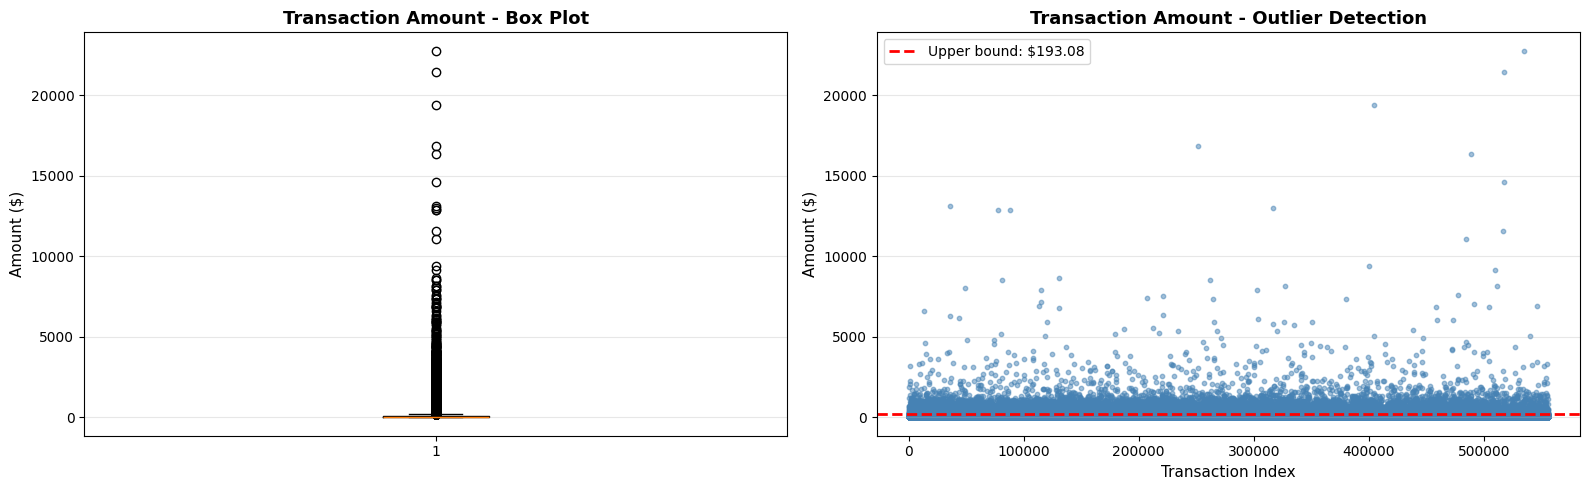

In [25]:
# Outlier detection using IQR method
print("="*60)
print("OUTLIER DETECTION (Transaction Amount)")
print("="*60)

Q1 = df['amt'].quantile(0.25)
Q3 = df['amt'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['amt'] < lower_bound) | (df['amt'] > upper_bound)]

print(f"\nQ1 (25th percentile): ${Q1:.2f}")
print(f"Q3 (75th percentile): ${Q3:.2f}")
print(f"IQR: ${IQR:.2f}")
print(f"Lower bound: ${lower_bound:.2f}")
print(f"Upper bound: ${upper_bound:.2f}")
print(f"\nNumber of outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Fraudulent outliers: {outliers['is_fraud'].sum():,} ({outliers['is_fraud'].mean()*100:.2f}%)")

# Visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Box plot
axes[0].boxplot(df['amt'])
axes[0].set_title('Transaction Amount - Box Plot', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Amount ($)', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Scatter plot
axes[1].scatter(range(len(df)), df['amt'], alpha=0.5, s=10, color='steelblue')
axes[1].axhline(upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper bound: ${upper_bound:.2f}')
axes[1].set_title('Transaction Amount - Outlier Detection', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Transaction Index', fontsize=11)
axes[1].set_ylabel('Amount ($)', fontsize=11)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Key Insights and Summary

In [26]:
print("="*70)
print("KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS")
print("="*70)

print("\n1. DATASET CHARACTERISTICS:")
print(f"   • Total transactions: {len(df):,}")
print(f"   • Features: {df.shape[1]}")
print(f"   • Time period: {df['trans_date_trans_time'].min().date()} to {df['trans_date_trans_time'].max().date()}")
print(f"   • No missing values detected")

print("\n2. CLASS IMBALANCE:")
print(f"   • Fraud rate: {df['is_fraud'].mean()*100:.2f}%")
print(f"   • Imbalance ratio: {df['is_fraud'].value_counts()[0]/df['is_fraud'].value_counts()[1]:.0f}:1")
print(f"   • Requires special handling (SMOTE, class weights, etc.)")

print("\n3. TRANSACTION AMOUNTS:")
print(f"   • Mean amount: ${df['amt'].mean():.2f}")
print(f"   • Median amount: ${df['amt'].median():.2f}")
print(f"   • Fraud mean: ${df[df['is_fraud']==1]['amt'].mean():.2f}")
print(f"   • Legitimate mean: ${df[df['is_fraud']==0]['amt'].mean():.2f}")
print(f"   • Fraud transactions have higher average amounts")

print("\n4. TEMPORAL PATTERNS:")
print(f"   • Peak fraud hours identified")
print(f"   • Day-of-week patterns observed")
print(f"   • Time-based features are valuable for prediction")

print("\n5. GEOGRAPHIC PATTERNS:")
top_fraud_states = state_fraud.head(3).index.tolist()
print(f"   • Highest fraud rates in: {', '.join(top_fraud_states)}")
print(f"   • State is a significant predictor")

print("\n6. CATEGORICAL FEATURES:")
top_fraud_categories = category_fraud.head(3).index.tolist()
print(f"   • Highest fraud categories: {', '.join(top_fraud_categories)}")
print(f"   • Category encoding essential for modeling")

print("\n7. CORRELATIONS:")
print(f"   • Amount shows correlation with fraud")
print(f"   • Other features show weak individual correlations")
print(f"   • Feature interactions likely important")

print("\n8. RECOMMENDATIONS FOR MODELING:")
print("   • Handle class imbalance (SMOTE, class weights)")
print("   • Encode categorical variables (category, gender, state)")
print("   • Use temporal features (hour, day_of_week)")
print("   • Consider ensemble methods (Random Forest, XGBoost)")
print("   • Focus on precision-recall metrics over accuracy")
print("   • Use ROC-AUC and PR-AUC for evaluation")

print("\n" + "="*70)
print("EDA COMPLETED SUCCESSFULLY")
print("="*70)

KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS

1. DATASET CHARACTERISTICS:
   • Total transactions: 555,719
   • Features: 28
   • Time period: 2020-06-21 to 2020-12-31
   • No missing values detected

2. CLASS IMBALANCE:
   • Fraud rate: 0.39%
   • Imbalance ratio: 258:1
   • Requires special handling (SMOTE, class weights, etc.)

3. TRANSACTION AMOUNTS:
   • Mean amount: $69.39
   • Median amount: $47.29
   • Fraud mean: $528.36
   • Legitimate mean: $67.61
   • Fraud transactions have higher average amounts

4. TEMPORAL PATTERNS:
   • Peak fraud hours identified
   • Day-of-week patterns observed
   • Time-based features are valuable for prediction

5. GEOGRAPHIC PATTERNS:
   • Highest fraud rates in: AK, CT, ID
   • State is a significant predictor

6. CATEGORICAL FEATURES:
   • Highest fraud categories: shopping_net, misc_net, grocery_pos
   • Category encoding essential for modeling

7. CORRELATIONS:
   • Amount shows correlation with fraud
   • Other features show weak individual 